# 05 — Kidney Disease Prediction: VitalsAI

This notebook trains a **Stacking Ensemble Pipeline** (Random Forest + XGBoost + SVC) on the Kidney Disease dataset to classify **5 severity levels** of chronic kidney disease.

**Classes:** No Disease | Low Risk | Moderate Risk | High Risk | Severe Disease

**Key steps:**
- Exploratory Data Analysis (EDA)
- Categorical encoding (Yes/No → 0/1)
- SMOTE for class imbalance
- Stacking Ensemble inside sklearn Pipeline
- Multi-class classification (5 stages)
- Model saving for VitalsAI deployment

## 1. Setup & Imports

In [1]:
# ── Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import joblib
import os
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, ConfusionMatrixDisplay)
from sklearn.feature_selection import SelectKBest, f_classif
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
print('Libraries loaded!')

Libraries loaded!


In [2]:
!pip install scikit-learn==1.6.1 xgboost==3.2.0 -q

## 2. Load Dataset
Loading the Kidney Disease dataset from Google Drive.

**Features:** Age, eGFR, Creatinine, Hypertension, Diabetes, Protein in Urine, etc.
**Target:** 5-class severity — No Disease → Severe Disease

In [4]:
from google.colab import drive

drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/kidney_disease_dataset.csv")

## 3. Exploratory Data Analysis (EDA)
### 3.1 Basic Info & Shape

In [6]:
print('Shape:', df.shape)
print(df.head())

Shape: (20538, 43)
   Age of the patient  Blood pressure (mm/Hg)  Specific gravity of urine  \
0                  54                     167                      1.023   
1                  42                     127                      1.023   
2                  38                     148                      1.016   
3                   7                      98                      1.017   
4                  67                     174                      1.015   

   Albumin in urine  Sugar in urine Red blood cells in urine  \
0                 1               4                   normal   
1                 3               2                   normal   
2                 0               0                 abnormal   
3                 4               0                 abnormal   
4                 1               1                   normal   

  Pus cells in urine Pus cell clumps in urine Bacteria in urine  \
0           abnormal              not present       not present   
1    

In [7]:
# ── Basic Info ─────────────────────────────────────────────
print(df.info())
print()
print(df.describe().T)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       20538 non-null  int64  
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  object 
 6   Pus cells in urine                           20538 non-null  object 
 7   Pus cell clumps in urine                     20538 non-null  object 
 8   Bacteria in urine                            20538 non-null  object 
 9   Random blood glucose level (mg/dl)           20538 non-null  int64  
 10

### 3.2 Missing Values

In [8]:
# ── Missing Values ─────────────────────────────────────────
print('Missing values:')
print(df.isnull().sum())

Missing values:
Age of the patient                             0
Blood pressure (mm/Hg)                         0
Specific gravity of urine                      0
Albumin in urine                               0
Sugar in urine                                 0
Red blood cells in urine                       0
Pus cells in urine                             0
Pus cell clumps in urine                       0
Bacteria in urine                              0
Random blood glucose level (mg/dl)             0
Blood urea (mg/dl)                             0
Serum creatinine (mg/dl)                       0
Sodium level (mEq/L)                           0
Potassium level (mEq/L)                        0
Hemoglobin level (gms)                         0
Packed cell volume (%)                         0
White blood cell count (cells/cumm)            0
Red blood cell count (millions/cumm)           0
Hypertension (yes/no)                          0
Diabetes mellitus (yes/no)                     0
Coro

### 3.3 Target Distribution — 5 Severity Classes

Target distribution:
Target
No_Disease        16432
Low_Risk           2054
Moderate_Risk       821
High_Risk           821
Severe_Disease      410
Name: count, dtype: int64

Target % distribution:
Target
No_Disease        80.01
Low_Risk          10.00
Moderate_Risk      4.00
High_Risk          4.00
Severe_Disease     2.00
Name: count, dtype: float64


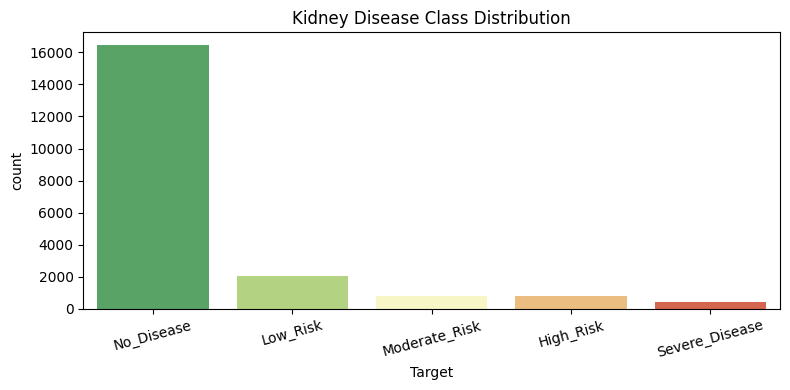

In [9]:
# ── Target Distribution ────────────────────────────────────
print('Target distribution:')
print(df['Target'].value_counts())
print()
print('Target % distribution:')
print((df['Target'].value_counts() / len(df) * 100).round(2))

plt.figure(figsize=(8, 4))
sns.countplot(x='Target', data=df,
              order=['No_Disease','Low_Risk','Moderate_Risk','High_Risk','Severe_Disease'],
              palette='RdYlGn_r')
plt.title('Kidney Disease Class Distribution')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 3.4 Numeric Feature Distributions

Numeric columns (28): ['Age of the patient', 'Blood pressure (mm/Hg)', 'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine', 'Random blood glucose level (mg/dl)', 'Blood urea (mg/dl)', 'Serum creatinine (mg/dl)', 'Sodium level (mEq/L)', 'Potassium level (mEq/L)', 'Hemoglobin level (gms)', 'Packed cell volume (%)', 'White blood cell count (cells/cumm)', 'Red blood cell count (millions/cumm)', 'Estimated Glomerular Filtration Rate (eGFR)', 'Urine protein-to-creatinine ratio', 'Urine output (ml/day)', 'Serum albumin level', 'Cholesterol level', 'Parathyroid hormone (PTH) level', 'Serum calcium level', 'Serum phosphate level', 'Body Mass Index (BMI)', 'Duration of diabetes mellitus (years)', 'Duration of hypertension (years)', 'Cystatin C level', 'C-reactive protein (CRP) level', 'Interleukin-6 (IL-6) level']


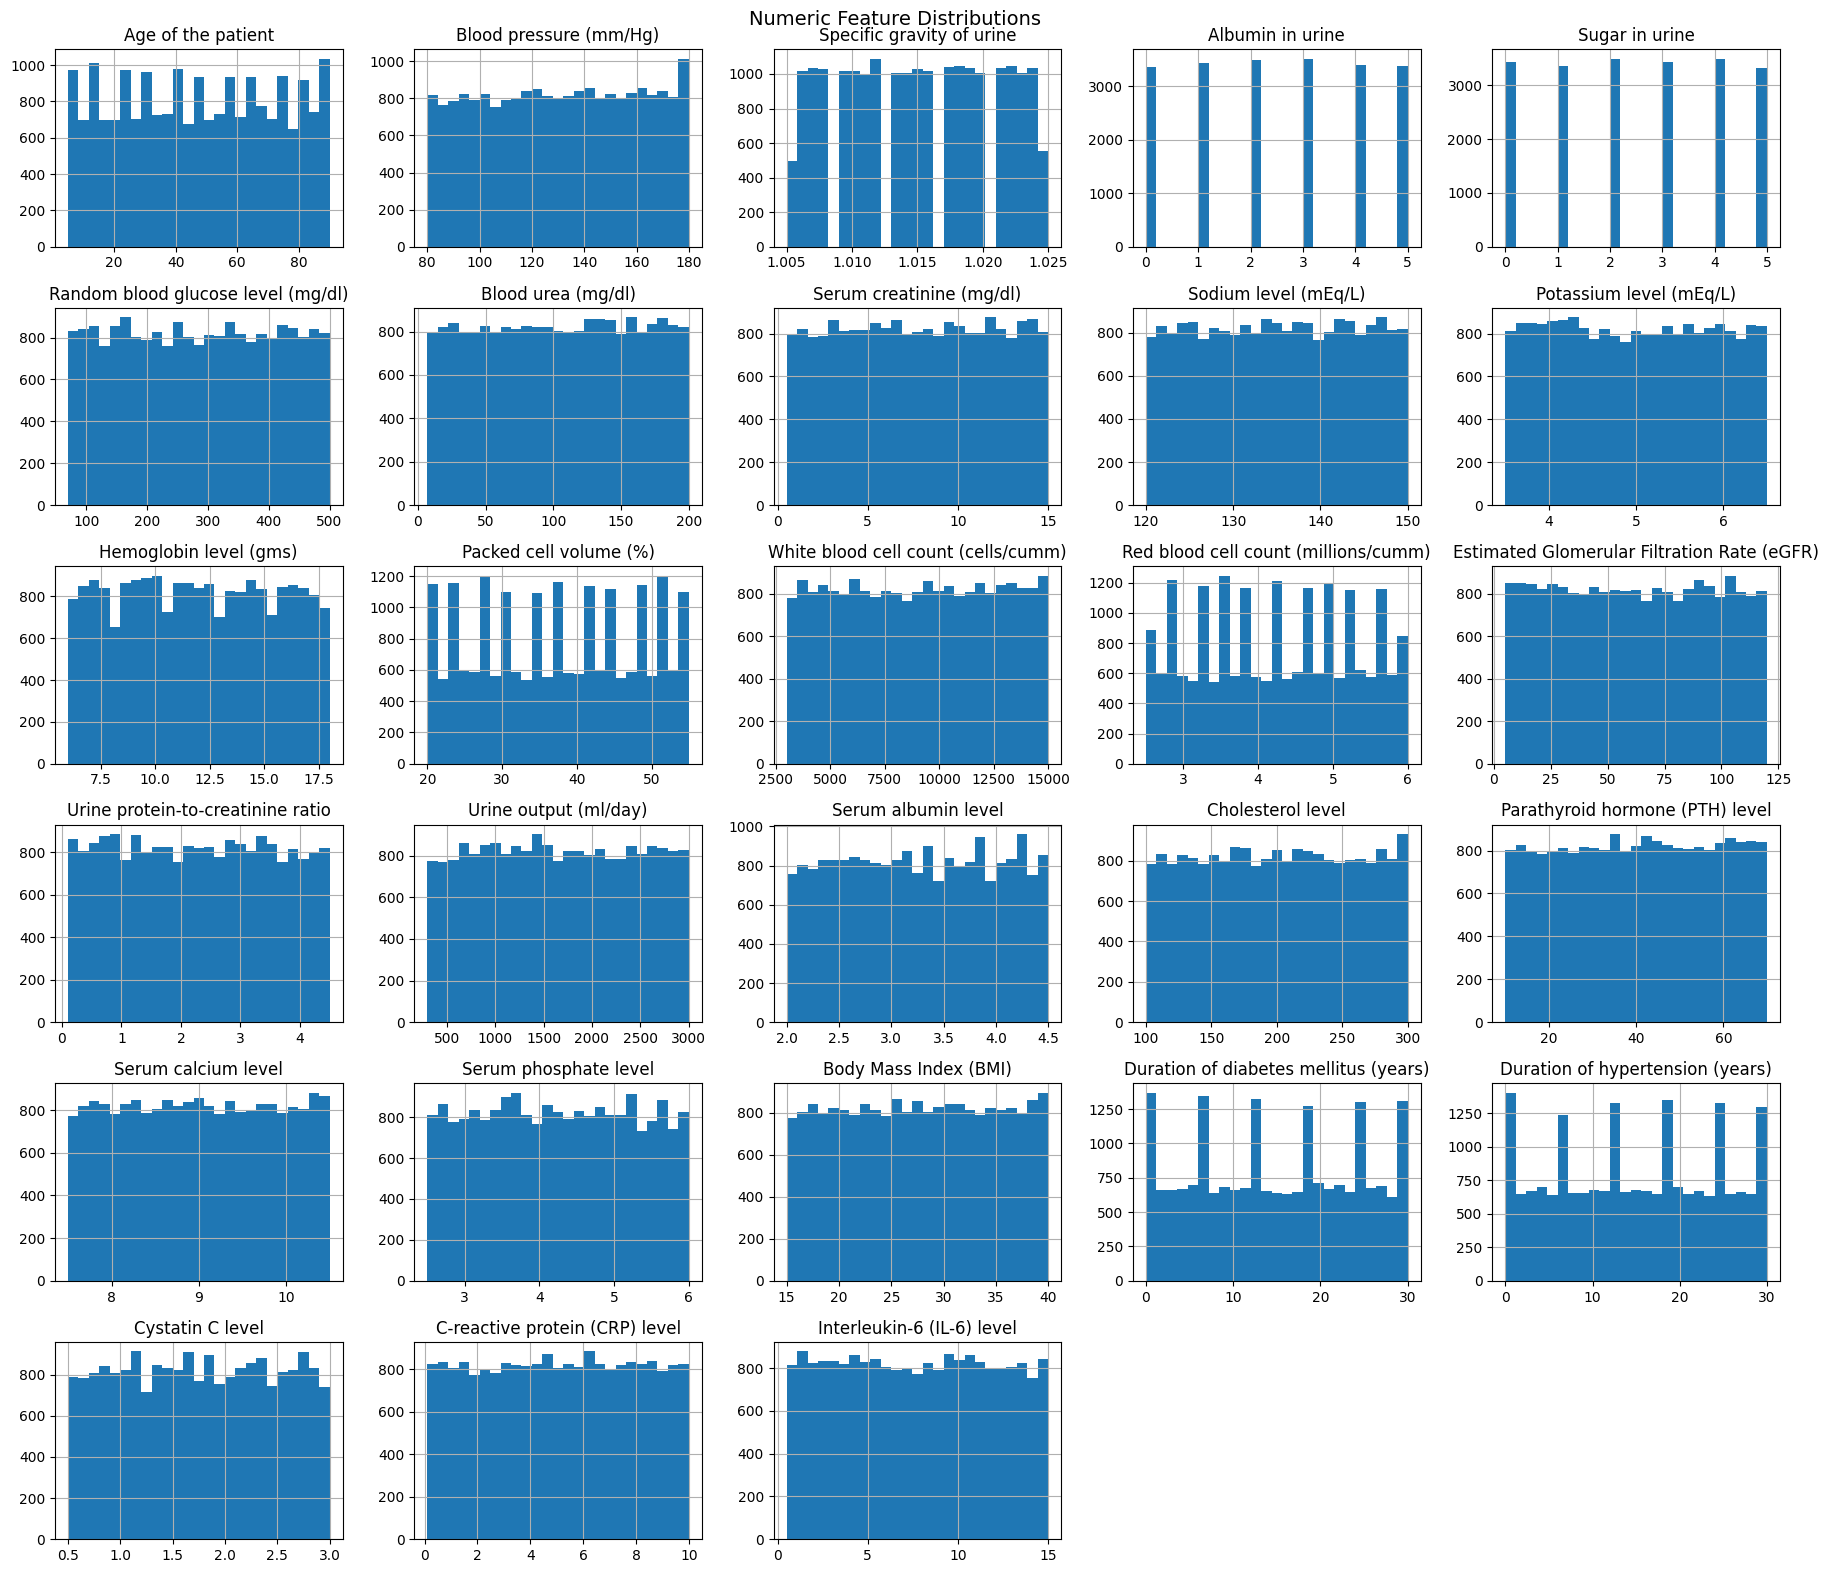

In [10]:
# ── Numeric Feature Distributions ─────────────────────────
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'Numeric columns ({len(numeric_cols)}):', numeric_cols)

df[numeric_cols].hist(bins=25, figsize=(18, 16))
plt.suptitle('Numeric Feature Distributions', fontsize=14)
plt.tight_layout()
plt.show()

### 3.5 Key Features vs Target (eGFR, Creatinine, Age)

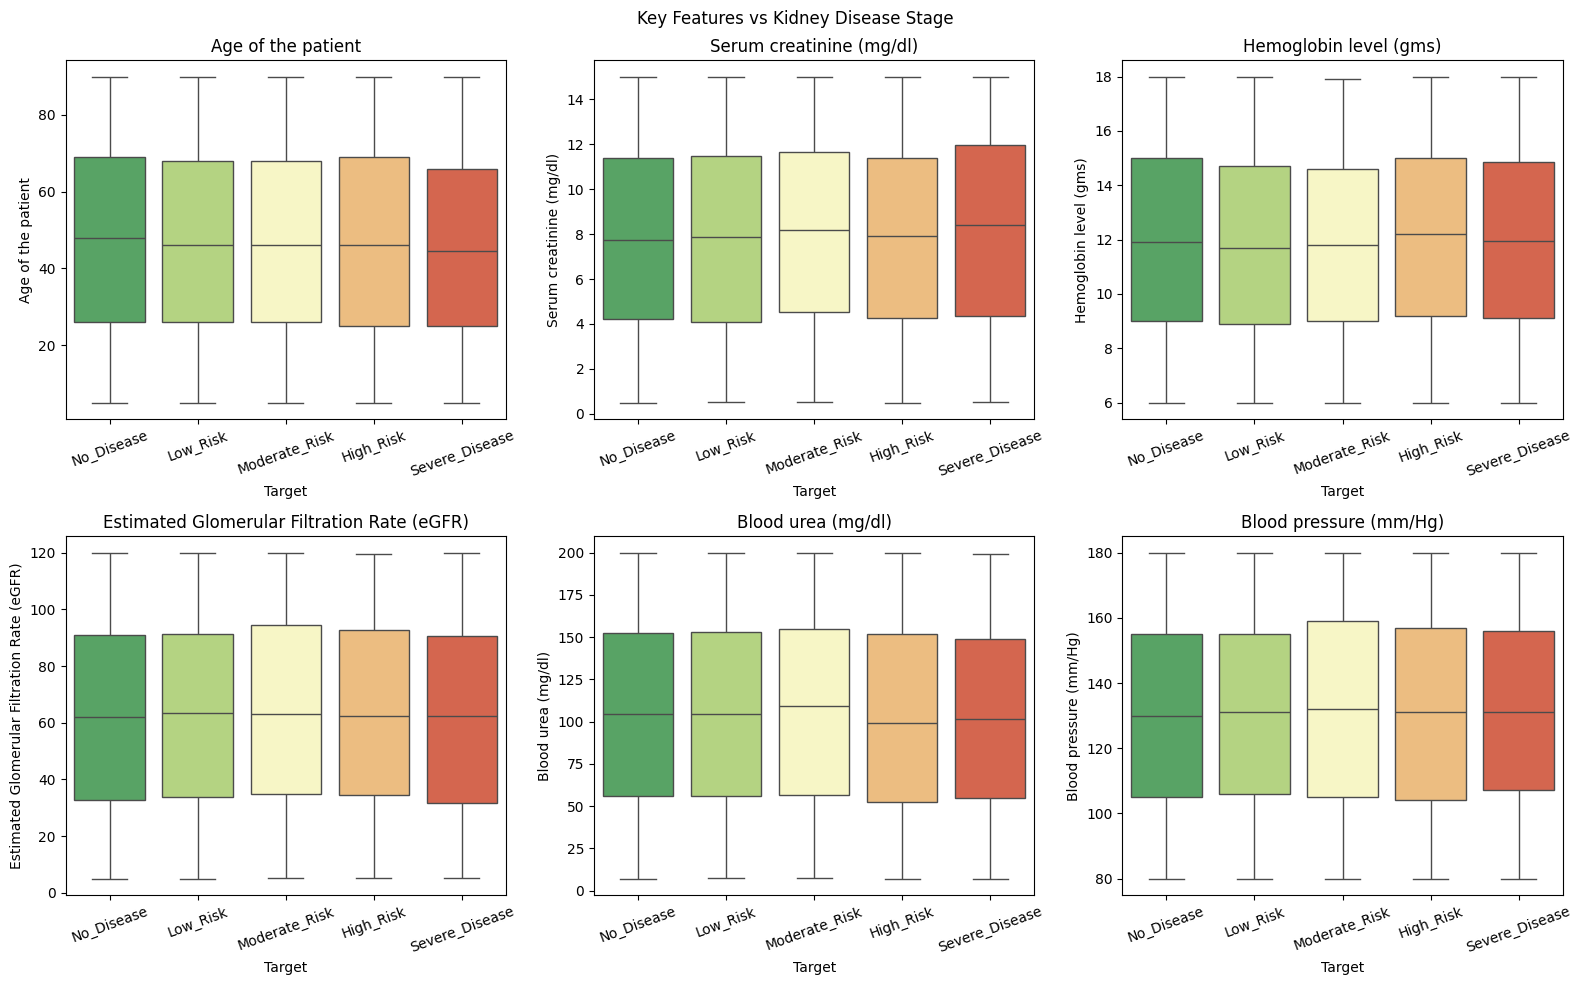

In [11]:
# ── Key Features vs Target ─────────────────────────────────
key_features = [
    'Age of the patient',
    'Serum creatinine (mg/dl)',
    'Hemoglobin level (gms)',
    'Estimated Glomerular Filtration Rate (eGFR)',
    'Blood urea (mg/dl)',
    'Blood pressure (mm/Hg)'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
order = ['No_Disease','Low_Risk','Moderate_Risk','High_Risk','Severe_Disease']
for i, col in enumerate(key_features):
    sns.boxplot(x='Target', y=col, data=df, order=order,
                palette='RdYlGn_r', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=20)
plt.suptitle('Key Features vs Kidney Disease Stage')
plt.tight_layout()
plt.show()

### 3.6 Categorical Features vs Target

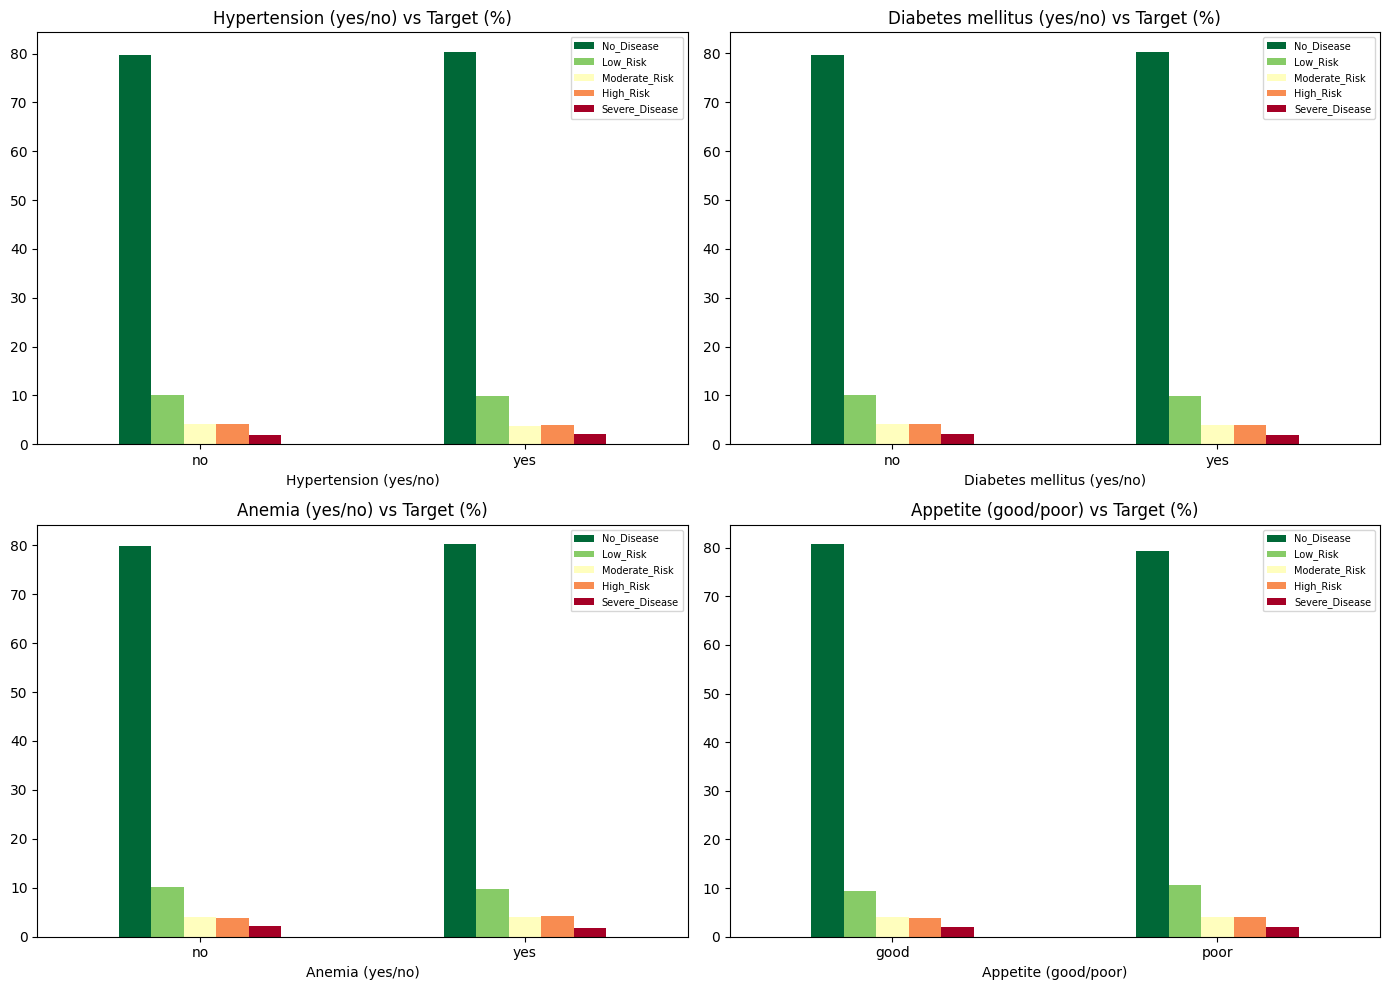

In [12]:
# ── Categorical Features vs Target ─────────────────────────
cat_cols = ['Hypertension (yes/no)', 'Diabetes mellitus (yes/no)',
            'Anemia (yes/no)', 'Appetite (good/poor)']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Target'], normalize='index') * 100
    ct[order].plot(kind='bar', ax=axes[i], colormap='RdYlGn_r', rot=0)
    axes[i].set_title(f'{col} vs Target (%)')
    axes[i].legend(fontsize=7)
plt.tight_layout()
plt.show()

### 3.7 Correlation Heatmap

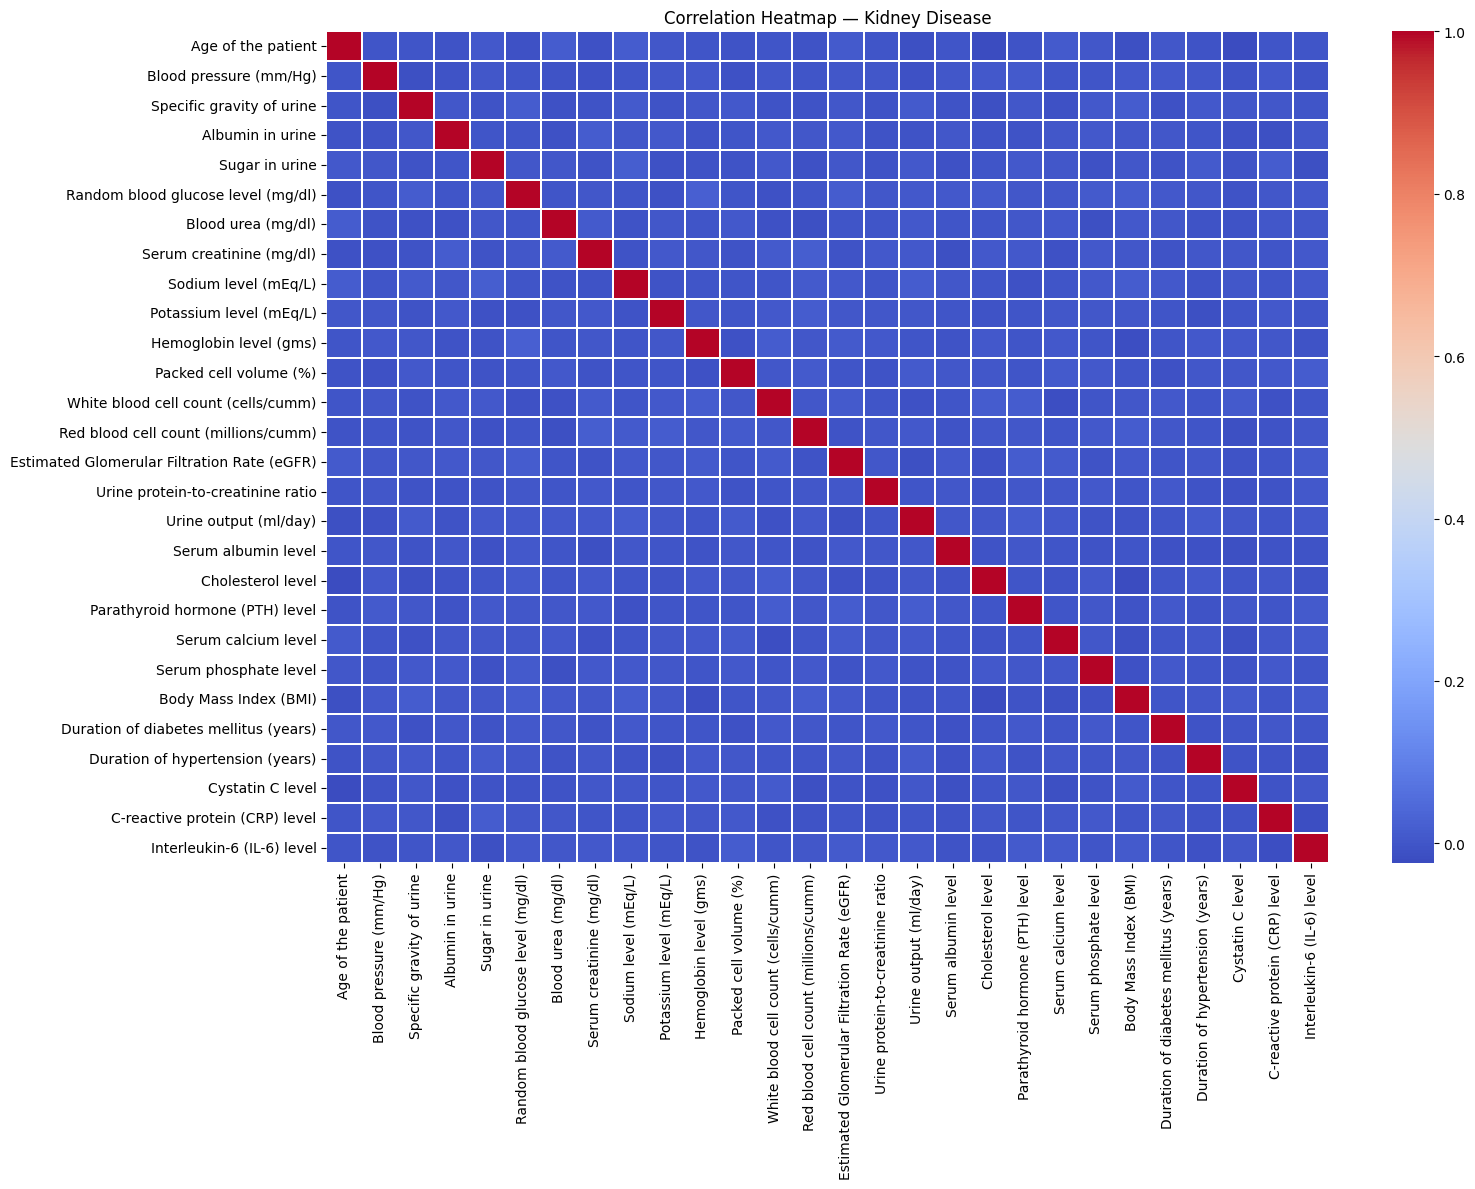


Top correlations with eGFR:
Estimated Glomerular Filtration Rate (eGFR)    1.000000
Parathyroid hormone (PTH) level                0.013725
Random blood glucose level (mg/dl)             0.012710
Age of the patient                             0.011987
Hemoglobin level (gms)                         0.011868
Serum calcium level                            0.009846
Interleukin-6 (IL-6) level                     0.009720
White blood cell count (cells/cumm)            0.008768
Albumin in urine                               0.006599
Body Mass Index (BMI)                          0.006531
Name: Estimated Glomerular Filtration Rate (eGFR), dtype: float64


In [13]:
# ── Correlation Heatmap ────────────────────────────────────
plt.figure(figsize=(16, 12))
sns.heatmap(df[numeric_cols].corr(), annot=False,
            cmap='coolwarm', linewidths=0.3)
plt.title('Correlation Heatmap — Kidney Disease')
plt.tight_layout()
plt.show()

# Top correlations with eGFR (key kidney metric)
corr = df[numeric_cols].corr()
egfr_corr = corr['Estimated Glomerular Filtration Rate (eGFR)'].sort_values(ascending=False)
print('\nTop correlations with eGFR:')
print(egfr_corr.head(10))

### 3.8 Outlier Detection (IQR Method)

In [14]:
# ── Outlier Detection (IQR) ────────────────────────────────
print('Outlier Count (IQR Method):')
for col in numeric_cols[:10]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    out = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col[:40]}: {len(out)} ({len(out)/len(df)*100:.1f}%)')

Outlier Count (IQR Method):
  Age of the patient: 0 (0.0%)
  Blood pressure (mm/Hg): 0 (0.0%)
  Specific gravity of urine: 0 (0.0%)
  Albumin in urine: 0 (0.0%)
  Sugar in urine: 0 (0.0%)
  Random blood glucose level (mg/dl): 0 (0.0%)
  Blood urea (mg/dl): 0 (0.0%)
  Serum creatinine (mg/dl): 0 (0.0%)
  Sodium level (mEq/L): 0 (0.0%)
  Potassium level (mEq/L): 0 (0.0%)


### 3.9 Group Statistics — Mean eGFR & Creatinine by Disease Stage

In [15]:
# ── Group Statistics ───────────────────────────────────────
print('Mean eGFR and Creatinine by Disease Stage:')
print(df.groupby('Target')[[
    'Estimated Glomerular Filtration Rate (eGFR)',
    'Serum creatinine (mg/dl)',
    'Hemoglobin level (gms)'
]].mean().round(2))

Mean eGFR and Creatinine by Disease Stage:
                Estimated Glomerular Filtration Rate (eGFR)  \
Target                                                        
High_Risk                                             63.06   
Low_Risk                                              63.07   
Moderate_Risk                                         64.05   
No_Disease                                            62.02   
Severe_Disease                                        61.17   

                Serum creatinine (mg/dl)  Hemoglobin level (gms)  
Target                                                            
High_Risk                           7.78                   12.07  
Low_Risk                            7.82                   11.83  
Moderate_Risk                       8.03                   11.83  
No_Disease                          7.76                   11.98  
Severe_Disease                      8.12                   11.92  


## 4. Preprocessing — Categorical Encoding
Encoding Yes/No columns to 0/1 and label encoding the target variable (5 classes).

In [16]:

# ── Encode Categorical Columns ─────────────────────────────
df_enc = df.copy()

# Binary yes/no columns
binary_map = {'yes': 1, 'no': 0,
              'normal': 1, 'abnormal': 0,
              'present': 1, 'not present': 0,
              'good': 1, 'poor': 0}

# Only use 'object' for string/categorical columns
cat_cols_all = df_enc.select_dtypes(include=['object']).columns.tolist()

cat_cols_all.remove('Target')

le = LabelEncoder()
for col in cat_cols_all:
    # Try binary map first
    unique_vals = df_enc[col].str.lower().unique()
    mapped = df_enc[col].str.lower().map(binary_map)
    if mapped.isnull().sum() == 0:
        df_enc[col] = mapped.astype(int)
    else:
        df_enc[col] = le.fit_transform(df_enc[col].astype(str))

# Encode Target
target_order = {'No_Disease': 0, 'Low_Risk': 1,
                'Moderate_Risk': 2, 'High_Risk': 3, 'Severe_Disease': 4}
df_enc['Target'] = df_enc['Target'].map(target_order)

print('Encoding done!')
print('Target mapping:', target_order)
print(df_enc.dtypes)

Encoding done!
Target mapping: {'No_Disease': 0, 'Low_Risk': 1, 'Moderate_Risk': 2, 'High_Risk': 3, 'Severe_Disease': 4}
Age of the patient                               int64
Blood pressure (mm/Hg)                           int64
Specific gravity of urine                      float64
Albumin in urine                                 int64
Sugar in urine                                   int64
Red blood cells in urine                         int64
Pus cells in urine                               int64
Pus cell clumps in urine                         int64
Bacteria in urine                                int64
Random blood glucose level (mg/dl)               int64
Blood urea (mg/dl)                             float64
Serum creatinine (mg/dl)                       float64
Sodium level (mEq/L)                           float64
Potassium level (mEq/L)                        float64
Hemoglobin level (gms)                         float64
Packed cell volume (%)                           int64

## 5. Feature / Target Split & Train-Test Split

In [17]:

# ── Feature / Target Split ─────────────────────────────────
X = df_enc.drop('Target', axis=1)
y = df_enc['Target']

print(f'Features: {X.shape[1]}')
print('Class distribution:', Counter(y))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print('Train:', X_train.shape, '| Test:', X_test.shape)

Features: 42
Class distribution: Counter({0: 16432, 1: 2054, 2: 821, 3: 821, 4: 410})
Train: (16430, 42) | Test: (4108, 42)


## 6. Handling Class Imbalance — SMOTE
Applying SMOTE to balance all 5 severity classes for fair multi-class learning.

In [18]:
# ── SMOTE — Balance Classes ────────────────────────────────
from imblearn.over_sampling import SMOTE
from collections import Counter

feature_names = list(X_train.columns)

# k_neighbors=3 for small minority classes
smote = SMOTE(random_state=42, k_neighbors=3)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print('After SMOTE:', Counter(y_train_res))


After SMOTE: Counter({0: 13145, 3: 13145, 1: 13145, 4: 13145, 2: 13145})


## 7. Stacking Ensemble Pipeline
Building a full sklearn Pipeline:
- **Preprocessor:** StandardScaler
- **Base learners:** Random Forest + XGBoost + SVC
- **Meta-learner:** Logistic Regression (class_weight=balanced)

In [19]:
# ── Stacking Ensemble + Pipeline ───────────────────────────
base_learners = [
    ('rf',  RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                max_depth=10,
                min_samples_leaf=2,
                random_state=42)),
    ('xgb', XGBClassifier(
                n_estimators=200,
                max_depth=6,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric='mlogloss',
                use_label_encoder=False)),
    ('gb',  GradientBoostingClassifier(
                n_estimators=200,
                max_depth=5,
                learning_rate=0.05,
                subsample=0.8,
                random_state=42))
]

stacking = StackingClassifier(
    estimators=base_learners,
    final_estimator=LogisticRegression(
        max_iter=2000,
        C=1.0,
        class_weight='balanced',
        multi_class='auto'
    ),
    cv=5,
    stack_method='predict_proba'
)

# Pipeline — scaler + model ek sathe
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  stacking)
])

pipeline.fit(X_train_res, y_train_res)
print('Kidney pipeline trained!')


Kidney pipeline trained!


## 8. Model Evaluation
### 8.1 Classification Report — 5-Class Output

In [20]:
# ── Evaluation ─────────────────────────────────────────────
y_pred = pipeline.predict(X_test)

target_names = ['No_Disease', 'Low_Risk', 'Moderate_Risk', 'High_Risk', 'Severe_Disease']
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=target_names))

# ROC-AUC (multi-class)
y_proba = pipeline.predict_proba(X_test)
roc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
print(f'ROC-AUC (macro ovr): {round(roc, 4)}')

# Per-class accuracy
from sklearn.metrics import balanced_accuracy_score
print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')

# Check No_Disease predictions
import numpy as np
no_disease_mask = y_test == 0
if no_disease_mask.sum() > 0:
    nd_acc = (y_pred[no_disease_mask] == 0).mean()
    print(f'No_Disease recall: {nd_acc:.4f}')

disease_mask = y_test > 0
if disease_mask.sum() > 0:
    d_acc = (y_pred[disease_mask] > 0).mean()
    print(f'Disease detection rate: {d_acc:.4f}')


--- Classification Report ---
                precision    recall  f1-score   support

    No_Disease       0.80      0.82      0.81      3287
      Low_Risk       0.09      0.10      0.10       411
 Moderate_Risk       0.03      0.02      0.02       164
     High_Risk       0.07      0.05      0.06       164
Severe_Disease       0.03      0.01      0.02        82

      accuracy                           0.67      4108
     macro avg       0.20      0.20      0.20      4108
  weighted avg       0.65      0.67      0.66      4108

ROC-AUC (macro ovr): 0.5222
Balanced Accuracy: 0.2016
No_Disease recall: 0.8181
Disease detection rate: 0.1571


### 8.2 Confusion Matrix

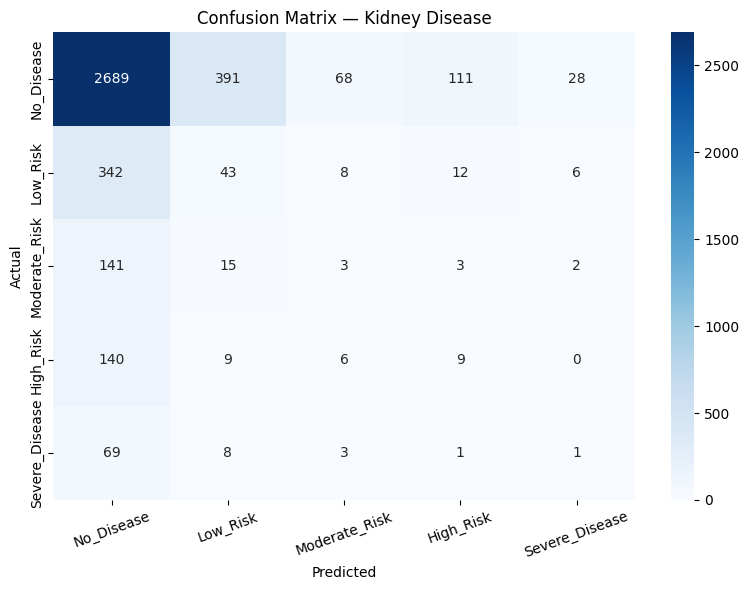

In [21]:
# ── Confusion Matrix ───────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix — Kidney Disease')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

### 8.3 Feature Importance

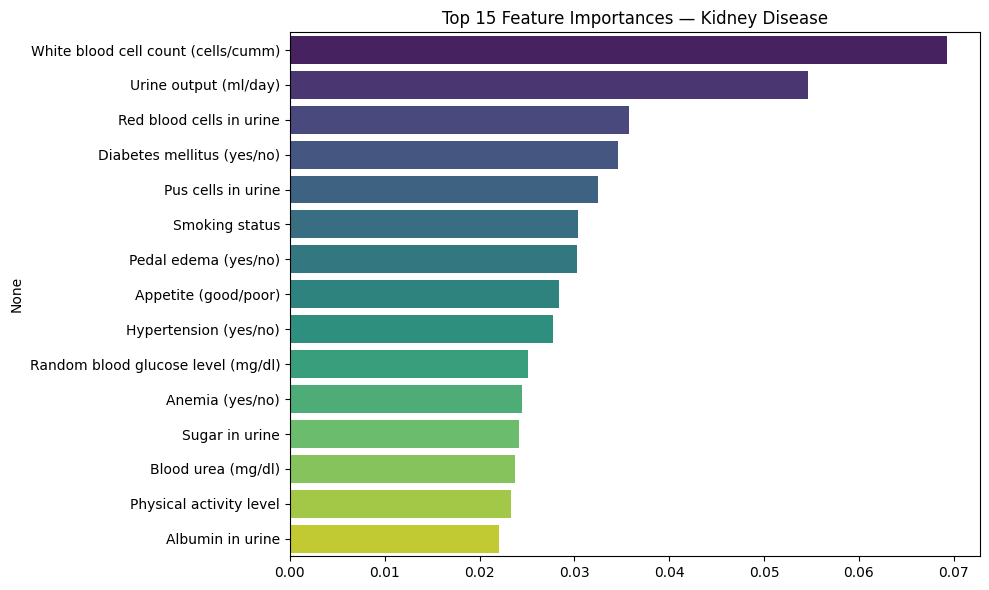

In [22]:
# ── Feature Importance ─────────────────────────────────────
rf_model = pipeline.named_steps['model'].named_estimators_['rf']
importances = rf_model.feature_importances_
feat_df = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=feat_df.values, y=feat_df.index, palette='viridis')
plt.title('Top 15 Feature Importances — Kidney Disease')
plt.tight_layout()
plt.show()

### 8.4 Cross-Validation (5-Fold)

In [23]:
# ── Cross Validation ───────────────────────────────────────
cv_scores = cross_val_score(pipeline, X, y, cv=3, scoring='accuracy')
print(f'Cross-validated Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Cross-validated Accuracy: 0.0976 ± 0.0273


## 9. Save Model for VitalsAI Deployment
Saving 3 files:
- `kidney_pipeline.pkl` — Full sklearn pipeline
- `kidney_features.pkl` — Feature column names
- `kidney_target_map.pkl` — Label → Class name mapping

In [24]:
# ── Save Pipeline ──────────────────────────────────────────
import joblib, os

# Local models folder ma save
os.makedirs('models', exist_ok=True)
joblib.dump(pipeline,      'models/kidney_pipeline.pkl')
joblib.dump(feature_names, 'models/kidney_features.pkl')
joblib.dump(target_order,  'models/kidney_target_map.pkl')
print('Saved locally!')

# Google Drive ma pan save karo (backup)
try:
    os.makedirs('/content/drive/MyDrive/VitalsAI_models', exist_ok=True)
    joblib.dump(pipeline,      '/content/drive/MyDrive/VitalsAI_models/kidney_pipeline.pkl')
    joblib.dump(feature_names, '/content/drive/MyDrive/VitalsAI_models/kidney_features.pkl')
    joblib.dump(target_order,  '/content/drive/MyDrive/VitalsAI_models/kidney_target_map.pkl')
    print('Saved to Google Drive!')
except:
    print('Google Drive save skipped (not mounted)')

print('Saved: models/kidney_pipeline.pkl')
print('Saved: models/kidney_features.pkl')
print('Saved: models/kidney_target_map.pkl')
print('Features:', feature_names[:5], '...')


Saved locally!
Saved to Google Drive!
Saved: models/kidney_pipeline.pkl
Saved: models/kidney_features.pkl
Saved: models/kidney_target_map.pkl
Features: ['Age of the patient', 'Blood pressure (mm/Hg)', 'Specific gravity of urine', 'Albumin in urine', 'Sugar in urine'] ...


## 10. Prediction Function & Sample Test

In [25]:
# ── Prediction Function ────────────────────────────────────
reverse_target = {v: k for k, v in target_order.items()}

def kidney_risk_analyzer(pipelxine, patient_df):
    pred_class = pipeline.predict(patient_df)[0]
    proba      = pipeline.predict_proba(patient_df)[0]
    confidence = round(float(max(proba)) * 100, 2)
    label      = reverse_target[pred_class]
    return label, confidence, proba

# Test with first sample
test_sample = X_test.iloc[[0]]
label, conf, proba = kidney_risk_analyzer(pipeline, test_sample)
actual = reverse_target[y_test.iloc[0]]

print('--- SAMPLE TEST ---')
print(f'Prediction  : {label}')
print(f'Confidence  : {conf}%')
print(f'Actual      : {actual}')

--- SAMPLE TEST ---
Prediction  : No_Disease
Confidence  : 91.27%
Actual      : Low_Risk


In [26]:
# ── Manual Test ────────────────────────────────────────────
import joblib
import pandas as pd

pipeline      = joblib.load('models/kidney_pipeline.pkl')
feature_names = joblib.load('models/kidney_features.pkl')
target_map    = joblib.load('models/kidney_target_map.pkl')
reverse_map   = {v: k for k, v in target_map.items()}

# High risk patient values
# Fill all features — 0 for unknown binary, median for numeric
patient = {
    'Age of the patient': 65,
    'Blood pressure (mm/Hg)': 160,
    'Specific gravity of urine': 1.010,
    'Albumin in urine': 4,
    'Sugar in urine': 2,
    'Red blood cells in urine': 0,       # abnormal=0
    'Pus cells in urine': 0,             # abnormal=0
    'Pus cell clumps in urine': 1,       # present=1
    'Bacteria in urine': 1,              # present=1
    'Random blood glucose level (mg/dl)': 250,
    'Blood urea (mg/dl)': 80,
    'Serum creatinine (mg/dl)': 5.5,
    'Sodium level (mEq/L)': 130,
    'Potassium level (mEq/L)': 5.5,
    'Hemoglobin level (gms)': 8.5,
    'Packed cell volume (%)': 25,
    'White blood cell count (cells/cumm)': 12000,
    'Red blood cell count (millions/cumm)': 3.0,
    'Hypertension (yes/no)': 1,
    'Diabetes mellitus (yes/no)': 1,
    'Coronary artery disease (yes/no)': 1,
    'Appetite (good/poor)': 0,           # poor=0
    'Pedal edema (yes/no)': 1,
    'Anemia (yes/no)': 1,
    'Estimated Glomerular Filtration Rate (eGFR)': 15,
    'Urine protein-to-creatinine ratio': 3.5,
    'Urine output (ml/day)': 400,
    'Serum albumin level': 2.5,
    'Cholesterol level': 250,
    'Parathyroid hormone (PTH) level': 200,
    'Serum calcium level': 7.5,
    'Serum phosphate level': 6.5,
    'Family history of chronic kidney disease': 1,
    'Smoking status': 1,
    'Body Mass Index (BMI)': 32,
    'Physical activity level': 0,
    'Duration of diabetes mellitus (years)': 15,
    'Duration of hypertension (years)': 10,
    'Cystatin C level': 3.5,
    'Urinary sediment microscopy results': 1,
    'C-reactive protein (CRP) level': 25,
    'Interleukin-6 (IL-6) level': 15
}

df_patient = pd.DataFrame([patient])
df_patient = df_patient.reindex(columns=feature_names, fill_value=0)

pred_class = pipeline.predict(df_patient)[0]
proba      = pipeline.predict_proba(df_patient)[0]
label      = reverse_map[pred_class]
confidence = round(float(max(proba)) * 100, 2)

print('--- MANUAL TEST RESULT ---')
print(f'Prediction  : {label}')
print(f'Confidence  : {confidence}%')
print()
print('All class probabilities:')
for i, p in enumerate(proba):
    print(f'  {reverse_map[i]}: {round(p*100, 2)}%')

--- MANUAL TEST RESULT ---
Prediction  : No_Disease
Confidence  : 95.37%

All class probabilities:
  No_Disease: 95.37%
  Low_Risk: 2.07%
  Moderate_Risk: 1.65%
  High_Risk: 0.64%
  Severe_Disease: 0.27%
